# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [11]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [12]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)



TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [13]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [14]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))




## 5. Quick Inspection


In [15]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    inputs = Input(shape=(input_dim,), name="HAR_data")
    x = Dense(256, activation="relu", name="dense_1")(inputs)
    x = Dense(128, activation="relu", name="dense_2")(x)
    x = Dense(64, activation="relu", name="dense_3")(x)
    outputs = Dense(6, activation="softmax", name="classifier")(x)
    return Model(inputs, outputs, name="baseline_model")

    
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 HAR_data (InputLayer)       [(None, 561)]             0         
                                                                 
 dense_1 (Dense)             (None, 256)               143872    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 classifier (Dense)          (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 992us/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 979us/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 959us/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2388 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 968us/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/40
9

### Training Curves


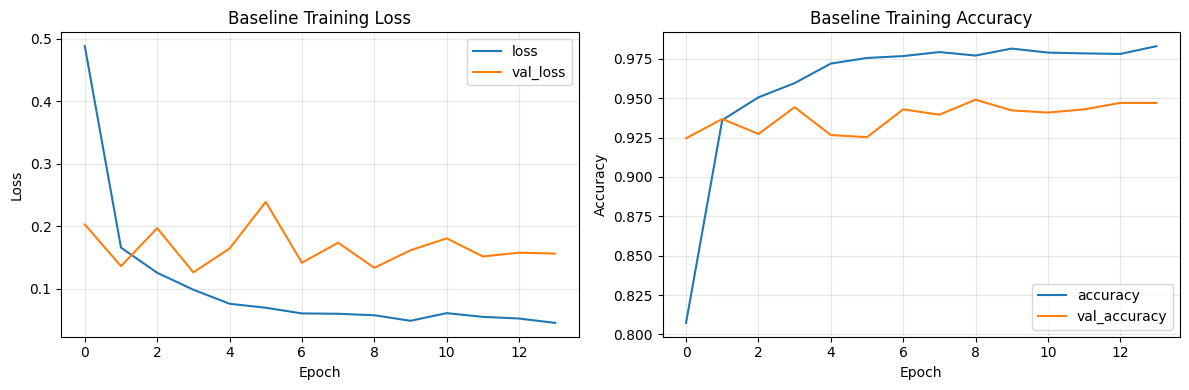

In [18]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

history_df = pd.DataFrame(history_baseline.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 401us/step
Test Accuracy: 0.9308

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       496
           1       0.96      0.91      0.93       471
           2       0.89      0.95      0.92       420
           3       0.95      0.86      0.90       491
           4       0.84      0.96      0.90       532
           5       1.00      0.95      0.97       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



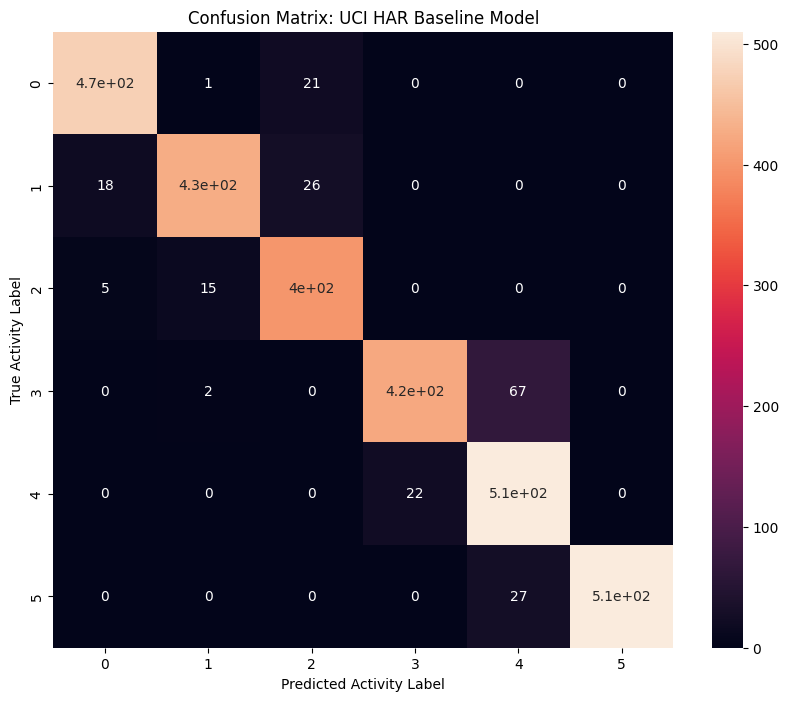

In [19]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = baseline_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True) 
plt.title('Confusion Matrix: UCI HAR Baseline Model')
plt.ylabel('True Activity Label')
plt.xlabel('Predicted Activity Label')
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [20]:
from pathlib import Path

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    
    num_samples = 300
    for sample in X_train[:num_samples]:
        yield [sample[np.newaxis, ...].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]
    
    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_dtype == np.int8:
            if input_scale == 0:
                raise ValueError("INT8 model has invalid input quantization scale 0.")
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_dtype == np.uint8:
            if input_scale == 0:
                raise ValueError("UINT8 model has invalid input quantization scale 0.")
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        elif input_dtype == np.float16:
            x = x.astype(np.float16)
        else:
            x = x.astype(input_dtype)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_dtype in (np.int8, np.uint8) and output_scale != 0:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # TODO: return the converted FP32 TensorFlow Lite model
    
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # TODO:
    # Apply default optimization and return the converted model.

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model_quantized = converter.convert()
    return tflite_model_quantized

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.supported_types = [tf.float16]
    tflite_model = converter.convert()
    return tflite_model
    

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model_int8 = converter.convert()
    return tflite_model_int8

def get_model_size_kb(model_path: Path) -> float:
    return model_path.stat().st_size / 1024.0

def build_results_table(rows):
    df = pd.DataFrame(rows)
    df["size_kb"] = df["size_kb"].round(2)
    df["accuracy"] = df["accuracy"].round(4)
    df["accuracy_drop_vs_keras_baseline"] = df["accuracy_drop_vs_keras_baseline"].round(4)
    return df


## 9. Post-Training Quantization (PTQ)


In [21]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.
import os
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
baseline_tflite_path = OUTPUT_DIR / "model_baseline.tflite"
dynamic_tflite_path = OUTPUT_DIR / "model_dynamic_quant.tflite"
float16_tflite_path = OUTPUT_DIR / "model_float16_quant.tflite"
int8_tflite_path = OUTPUT_DIR / "model_integer_quant.tflite"

# Baseline TFLite
fp32_model = convert_to_tflite_fp32(baseline_model)
baseline_tflite_path.write_bytes(fp32_model)
size_kb = os.path.getsize(baseline_tflite_path) / 1024
print(f"Baseline Model Size: {size_kb:.2f} KB")

# Dynamic range quantization
dr_model = convert_to_tflite_dynamic_range(baseline_model)
dynamic_tflite_path.write_bytes(dr_model)
size_kb = os.path.getsize(dynamic_tflite_path) / 1024
print(f"Dynamic Range Quantization Model Size: {size_kb:.2f} KB")

# Float16 quantization
f16_model = convert_to_tflite_float16(baseline_model)
float16_tflite_path.write_bytes(f16_model)
size_kb = os.path.getsize(float16_tflite_path) / 1024
print(f"Float16 Quantization Model Size: {size_kb:.2f} KB")

# Full INT8 PTQ
int8_model = convert_to_tflite_int8(baseline_model)
int8_tflite_path.write_bytes(int8_model)
size_kb = os.path.getsize(int8_tflite_path) / 1024
print(f"Int8 Quantization Model Size: {size_kb:.2f} KB")

# Evaluate
ptq_rows = []

loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)

for model_name, model_path in [
    ("Baseline TFLite", baseline_tflite_path),
    ("PTQ INT8", int8_tflite_path),
    ("PTQ Dynamic Range", dynamic_tflite_path),
    ("PTQ Float16", float16_tflite_path),
]:
    results = evaluate_tflite_model(model_path.read_bytes(), X_test, y_test)
    acc = results[0]
    ptq_rows.append(
        {
            "model": model_name,
            "file": model_path.name,
            "size_kb": get_model_size_kb(model_path),
            "accuracy": acc,
            "accuracy_drop_vs_keras_baseline": baseline_accuracy - acc,
        }
    )

ptq_results = build_results_table(ptq_rows)
ptq_results


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt0job0fj/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt0job0fj/assets


Baseline Model Size: 726.83 KB


2026-04-20 18:41:39.206451: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 18:41:39.206467: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 18:41:39.206548: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt0job0fj
2026-04-20 18:41:39.206982: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 18:41:39.206985: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt0job0fj
2026-04-20 18:41:39.208028: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 18:41:39.226503: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt0job0fj
2026-04-

INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp4kl7wxmf/assets


...

Float16 Quantization Model Size: 186.22 KB
INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpu7q83s9p/assets


2026-04-20 18:41:39.791793: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp4gjdwbmw
2026-04-20 18:41:39.792256: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 18:41:39.792260: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp4gjdwbmw
2026-04-20 18:41:39.793298: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 18:41:39.811772: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp4gjdwbmw
2026-04-20 18:41:39.816378: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 24585 microseconds.
INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpu7q83s9p/assets
/Users/Ben

Int8 Quantization Model Size: 185.43 KB


2026-04-20 18:41:40.033735: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 18:41:40.033745: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 18:41:40.033817: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpu7q83s9p
2026-04-20 18:41:40.034228: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 18:41:40.034231: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpu7q83s9p
2026-04-20 18:41:40.035280: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 18:41:40.053306: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpu7q83s9p
2026-04-

,model,file,size_kb,accuracy,accuracy_drop_vs_keras_baseline
0,Baseline TFLite,model_baseline.tflite,726.83,0.9308,0.0000
1,PTQ INT8,model_integer_quant.tflite,185.43,0.9315,-0.0007
2,PTQ Dynamic Range,model_dynamic_quant.tflite,186.22,0.9308,0.0000
3,PTQ Float16,model_float16_quant.tflite,186.22,0.9308,0.0000


## 10. PTQ Comparison: Accuracy and Model Size


In [22]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

acc_fp32    = ptq_results.loc[ptq_results['model'] == "Baseline TFLite", "accuracy"].values[0]
acc_int8    = ptq_results.loc[ptq_results['model'] == "PTQ INT8", "accuracy"].values[0]
acc_dynamic = ptq_results.loc[ptq_results['model'] == "PTQ Dynamic Range", "accuracy"].values[0]
acc_f16     = ptq_results.loc[ptq_results['model'] == "PTQ Float16", "accuracy"].values[0]

print(f"Extracted INT8 Accuracy: {acc_int8:.4f}")

comparison_data = [
    {
        "Model Family": "Baseline",
        "Format": "TFLite (FP32)",
        "Size (KB)": round(os.path.getsize(baseline_tflite_path) / 1024, 2),
        "Test Accuracy": round(acc_fp32, 4),
    },
    {
        "Model Family": "Baseline",
        "Format": "TFLite (Dynamic)",
        "Size (KB)": round(os.path.getsize(dynamic_tflite_path) / 1024, 2),
        "Test Accuracy": round(acc_dynamic, 4),
    },
    {
        "Model Family": "Baseline",
        "Format": "TFLite (Float16)",
        "Size (KB)": round(os.path.getsize(float16_tflite_path) / 1024, 2),
        "Test Accuracy": round(acc_f16, 4),
    },
    {
        "Model Family": "Baseline",
        "Format": "TFLite (Int8)",
        "Size (KB)": round(os.path.getsize(int8_tflite_path) / 1024, 2),
        "Test Accuracy": round(acc_int8, 4),
    }
]

df_comparison = pd.DataFrame(comparison_data)

print("Model Comparison Summary:")
display(df_comparison)

Extracted INT8 Accuracy: 0.9315
Model Comparison Summary:


,Model Family,Format,Size (KB),Test Accuracy
0,Baseline,TFLite (FP32),726.83,0.9308
1,Baseline,TFLite (Dynamic),186.22,0.9308
2,Baseline,TFLite (Float16),186.22,0.9308
3,Baseline,TFLite (Int8),185.43,0.9315


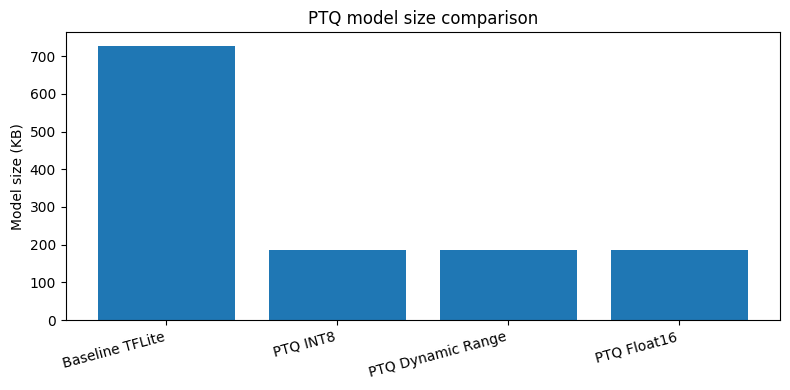

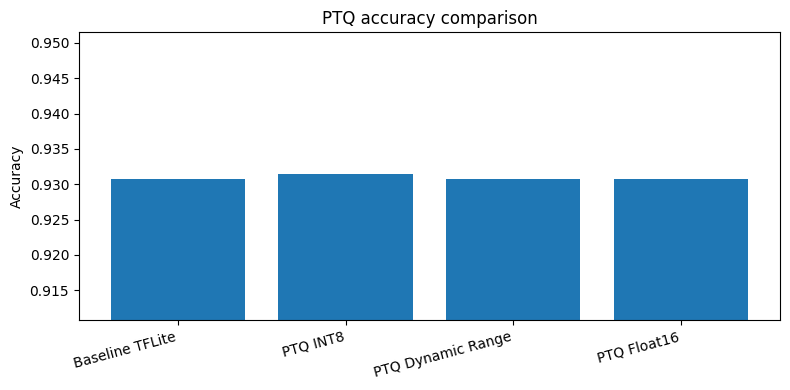

In [23]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

ptq_plot_df = ptq_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(ptq_plot_df["model"], ptq_plot_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("PTQ model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(ptq_plot_df["model"], ptq_plot_df["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(max(0.0, ptq_plot_df["accuracy"].min() - 0.02), min(1.0, ptq_plot_df["accuracy"].max() + 0.02))
plt.title("PTQ accuracy comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()



### Confusion Matrix for the PTQ Int8 Model


PTQ INT8 Test Accuracy: 0.9315

Classification Report (INT8):
                    precision    recall  f1-score   support

           WALKING       0.95      0.96      0.95       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.90      0.95      0.92       420
           SITTING       0.95      0.87      0.91       491
          STANDING       0.85      0.96      0.90       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



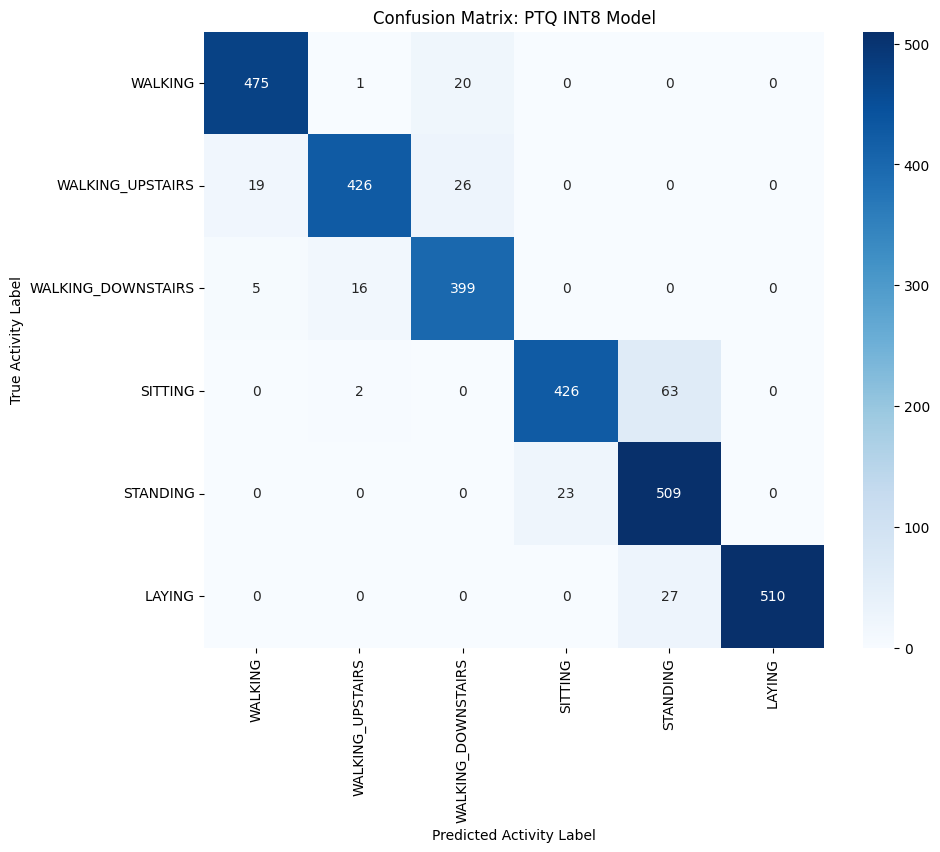

In [24]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

int8_acc, y_pred_int8 = evaluate_tflite_model(int8_tflite_path.read_bytes(), X_test, y_test)

print(f"PTQ INT8 Test Accuracy: {int8_acc:.4f}")
print()
print("Classification Report (INT8):")

print(classification_report(y_test, y_pred_int8, target_names=class_names))

cm_int8 = confusion_matrix(y_test, y_pred_int8)
plt.figure(figsize=(10, 8))

sns.heatmap(cm_int8, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: PTQ INT8 Model')
plt.ylabel('True Activity Label')
plt.xlabel('Predicted Activity Label')
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [25]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()


Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 HAR_data (InputLayer)       [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_1 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 64)                8261      
 pperV2)                                            

### Fine-Tune the QAT Model


In [26]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

history_qat = qat_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)

qat_loss, qat_accuracy = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT Keras test accuracy: {qat_accuracy:.4f}")


Epoch 1/8
115/115 [==============================] - 1s 2ms/step - loss: 0.1049 - accuracy: 0.9637 - val_loss: 0.1899 - val_accuracy: 0.9308
Epoch 2/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0641 - accuracy: 0.9761 - val_loss: 0.2709 - val_accuracy: 0.9277
Epoch 3/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0553 - accuracy: 0.9784 - val_loss: 0.1530 - val_accuracy: 0.9460
Epoch 4/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0497 - accuracy: 0.9800 - val_loss: 0.1573 - val_accuracy: 0.9474
Epoch 5/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0485 - accuracy: 0.9814 - val_loss: 0.1894 - val_accuracy: 0.9427
Epoch 6/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0557 - accuracy: 0.9804 - val_loss: 0.1629 - val_accuracy: 0.9437
Epoch 7/8
115/115 [==============================] - 0s 2ms/step - loss: 0.0628 - accuracy: 0.9737 - val_loss: 0.2536 - val_accuracy: 0.9260
Epoch 8/8
115

### Evaluate the QAT Keras Model


In [27]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_loss, qat_accuracy = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT Keras test accuracy: {qat_accuracy:.4f}")

y_pred_qat_probs = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_pred_qat_probs, axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT: QAT KERAS MODEL")
print("="*60)
# If you still don't have label_names, remove the target_names argument
print(classification_report(y_test, y_pred_qat, target_names=class_names))


QAT Keras test accuracy: 0.9237
93/93 [==============================] - 0s 527us/step

CLASSIFICATION REPORT: QAT KERAS MODEL
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.92      0.92      0.92       471
WALKING_DOWNSTAIRS       0.98      0.91      0.95       420
           SITTING       0.98      0.75      0.85       491
          STANDING       0.80      0.99      0.89       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [28]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_int8_tflite_path = OUTPUT_DIR / "qat_int8.tflite"
# Full INT8 PTQ

qat_int8_model = convert_to_tflite_int8(qat_model)
qat_int8_tflite_path.write_bytes(qat_int8_model)
size_kb = os.path.getsize(qat_int8_tflite_path) / 1024
print(f"QAT Int8 Quantization Model Size: {size_kb:.2f} KB")

qat_int8_accuracy, qat_y_pred = evaluate_tflite_model(qat_int8_model, X_test, y_test)
print(f"QAT INT8 Keras test accuracy: {qat_int8_accuracy:.4f}")


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpoc7hjl8c/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpoc7hjl8c/assets
/Users/Benjamin/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 18:41:51.131866: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 18:41:51.131877: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


QAT Int8 Quantization Model Size: 185.82 KB
QAT INT8 Keras test accuracy: 0.9237


2026-04-20 18:41:51.131964: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpoc7hjl8c
2026-04-20 18:41:51.132981: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 18:41:51.132988: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpoc7hjl8c
2026-04-20 18:41:51.135574: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 18:41:51.166691: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpoc7hjl8c
2026-04-20 18:41:51.175202: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 43237 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 12. PTQ Int8 vs QAT Int8


In [29]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)


acc_int8    = ptq_results.loc[ptq_results['model'] == "PTQ INT8", "accuracy"].values[0]

print(f"Extracted INT8 Accuracy: {acc_int8:.4f}")

comparison_data = [
    {
        "Model Family": "PTQ",
        "Size (KB)": round(os.path.getsize(int8_tflite_path) / 1024, 2),
        "Test Accuracy": round(acc_int8, 4),
    },
    {
        "Model Family": "QAT",
        "Size (KB)": round(os.path.getsize(qat_int8_tflite_path) / 1024, 2),
        "Test Accuracy": round(qat_int8_accuracy, 4),
    }
]

df_comparison = pd.DataFrame(comparison_data)

print("Model Comparison Summary:")
display(df_comparison)


Extracted INT8 Accuracy: 0.9315
Model Comparison Summary:


,Model Family,Size (KB),Test Accuracy
0,PTQ,185.43,0.9315
1,QAT,185.82,0.9237


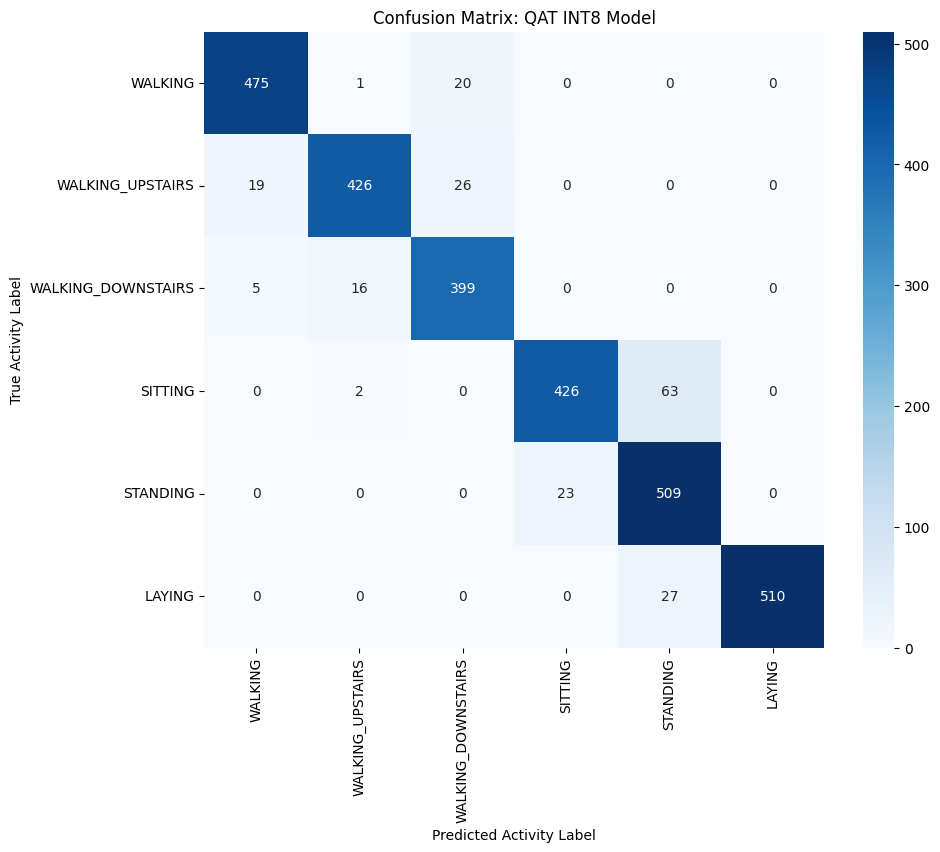

In [30]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

int8_acc, y_pred_int8_qat = evaluate_tflite_model(qat_int8_tflite_path.read_bytes(), X_test, y_test)

cm_int8 = confusion_matrix(y_test, y_pred_int8)
plt.figure(figsize=(10, 8))

sns.heatmap(cm_int8, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: QAT INT8 Model')
plt.ylabel('True Activity Label')
plt.xlabel('Predicted Activity Label')
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? The int8 quantization was the smallest.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models? Dynamic and float16 were tied for highest.
3. Did QAT improve the final int8 model compared with PTQ int8? Yes, it improved the accurracy by about 2%.
4. Why is this dataset a good fit for a DNN-based TinyML workflow? It has a high feature amount, which a dense neural network can easily map to specific activities.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose qat int8 quantization because it gives the smallest size and has very high accurracy.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
